In [1]:
from getdist import plots, loadMCSamples
from getdist.mcsamples import MCSamplesFromCobaya
import getdist.plots as gdplt
import getdist as getdist
import matplotlib as mpl
import numpy as np

gdplot = gdplt.get_subplot_plotter()

gdplot.settings.legend_fontsize = 23
gdplot.settings.axes_fontsize = 15
gdplot.settings.lab_fontsize = 23
gdplot.settings.figure_legend_loc = 'upper right'

chains = '/home/s1/ggibbins/varyparams/chain/'



In [2]:
#Gal Auto
gal_chains = chains + 'clgg_only/chains_'
gal_samples = loadMCSamples(gal_chains, settings={'ignore_rows':.3}) #30% burn in

#WL Auto
wl_chains = chains + 'kgalkgal_only/chains_'
wl_samples = loadMCSamples(wl_chains, settings={'ignore_rows':.3}) #30% burn in

#Gal x CMB 
galcmb_chains = chains + 'kcmbg_only/chains_'
galcmb_samples = loadMCSamples(galcmb_chains, settings={'ignore_rows':.3}) #30% burn in

#WL x CMB
wlcmb_chains = chains + 'kgalkcmb_only/chains_'
wlcmb_samples = loadMCSamples(wlcmb_chains, settings={'ignore_rows':.3}) #30% burn in

#Gal x CMB & WL x CMB Combined
crosscombo_chains = chains + 'kcmbg_kcmbk_combined/chains_'
crosscombo_samples = loadMCSamples(crosscombo_chains, settings={'ignore_rows':.3}) #30% burn in

#ALL Probes Combined
all_chains = chains + 'gg_kk_kcmbg_kcmbk_combined/chains_'
all_samples = loadMCSamples(all_chains, settings={'ignore_rows':.3}) #30% burn in

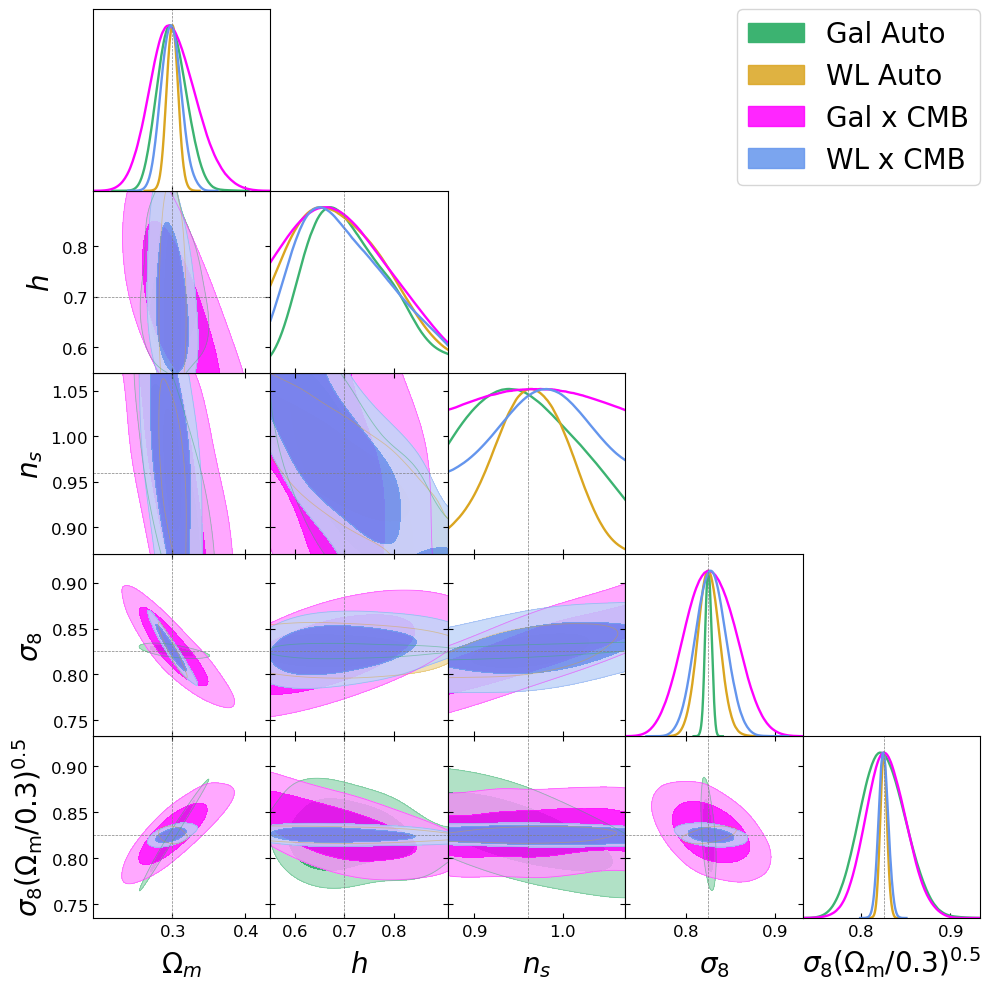

In [69]:
#WL x CMB constant de ALL param corner plot
##ADDDDDD OMEGA M & S8 FID VALUE WHEN FIGURE OUT
gdplot.triangle_plot([gal_samples, wl_samples, galcmb_samples, wlcmb_samples], 
                     ["Omega_m","h","n_s","sigma8", "S8"], 
                     filled=True,
                     markers={"Omega_m":0.3, "h":0.7, "n_s":0.96, "sigma8":0.825395112586185, "S8":0.825395112586185},
                     legend_labels=['Gal Auto','WL Auto', 'Gal x CMB', 'WL x CMB'],
                     colors=['mediumseagreen','goldenrod','magenta','cornflowerblue'],
                     line_args=[{'lw':1.7, 'color':'mediumseagreen'}, {'lw':1.7,'color':'goldenrod'}, {'lw':1.7,'color':'magenta'}, {'lw':1.7,'color':'cornflowerblue'}])


gal_samples.getLatex() 
wl_samples.getLatex()
wlcmb_samples.getLatex()

gdplot.export(fname='indivcontours_plot.pdf', adir='/home/s1/ggibbins/varyparams/posterplots/')

(['\\Omega_c',
  '\\Omega_b',
  'h',
  'n_s',
  'A_s',
  '\\sigma_8',
  '\\Omega_m',
  '\\sigma_8 (\\Omega_\\mathrm{m}/0.3)^{0.5}',
  '\\chi^2',
  '\\chi^2_\\mathrm{like\\ kxg.like\\ kxg}'],
 ['0.247\\pm 0.017',
  '0.051^{+0.013}_{-0.010}',
  '0.702^{+0.063}_{-0.12}',
  '0.973^{+0.066}_{-0.052}',
  '2.22^{+0.31}_{-0.48}',
  '0.828\\pm 0.017',
  '0.298\\pm 0.014',
  '0.8253\\pm 0.0054',
  '3.4\\pm 2.5',
  '3.4\\pm 2.5'])

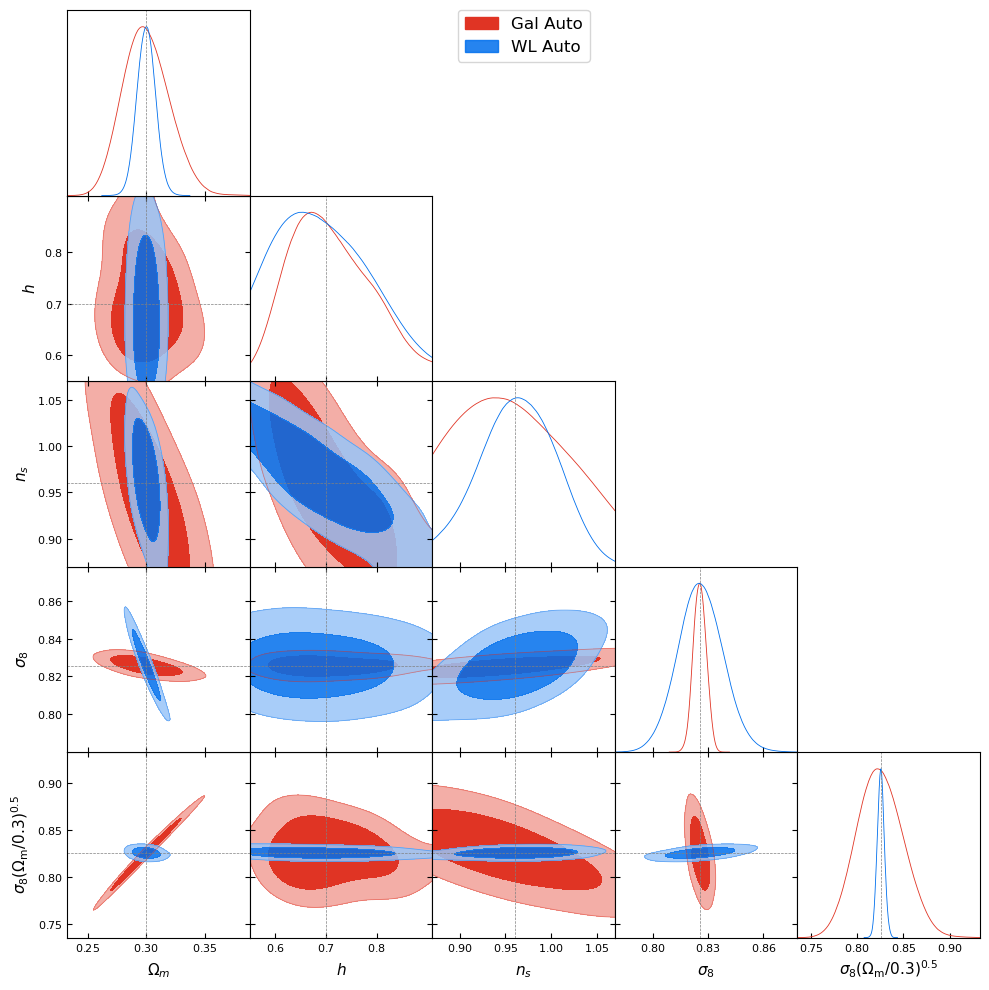

In [24]:
gdplot.triangle_plot([gal_samples, wl_samples], 
                     ["Omega_m","h","n_s","sigma8", "S8"], 
                     filled=True,
                     markers={"Omega_m":0.3, "h":0.7, "n_s":0.96, "sigma8":0.825395112586185, "S8":0.825395112586185},
                     legend_labels=['Gal Auto','WL Auto'])

gal_samples.getLatex() 
wl_samples.getLatex()

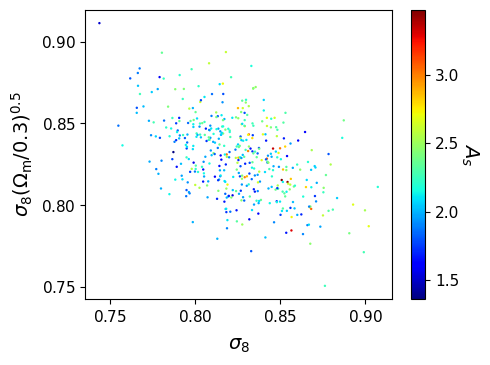

In [11]:
# 2D scatter (3D) plot
g = plots.get_single_plotter(width_inch=5)
g.plot_3d(samples, ["sigma8", "S8","A_sE9"])

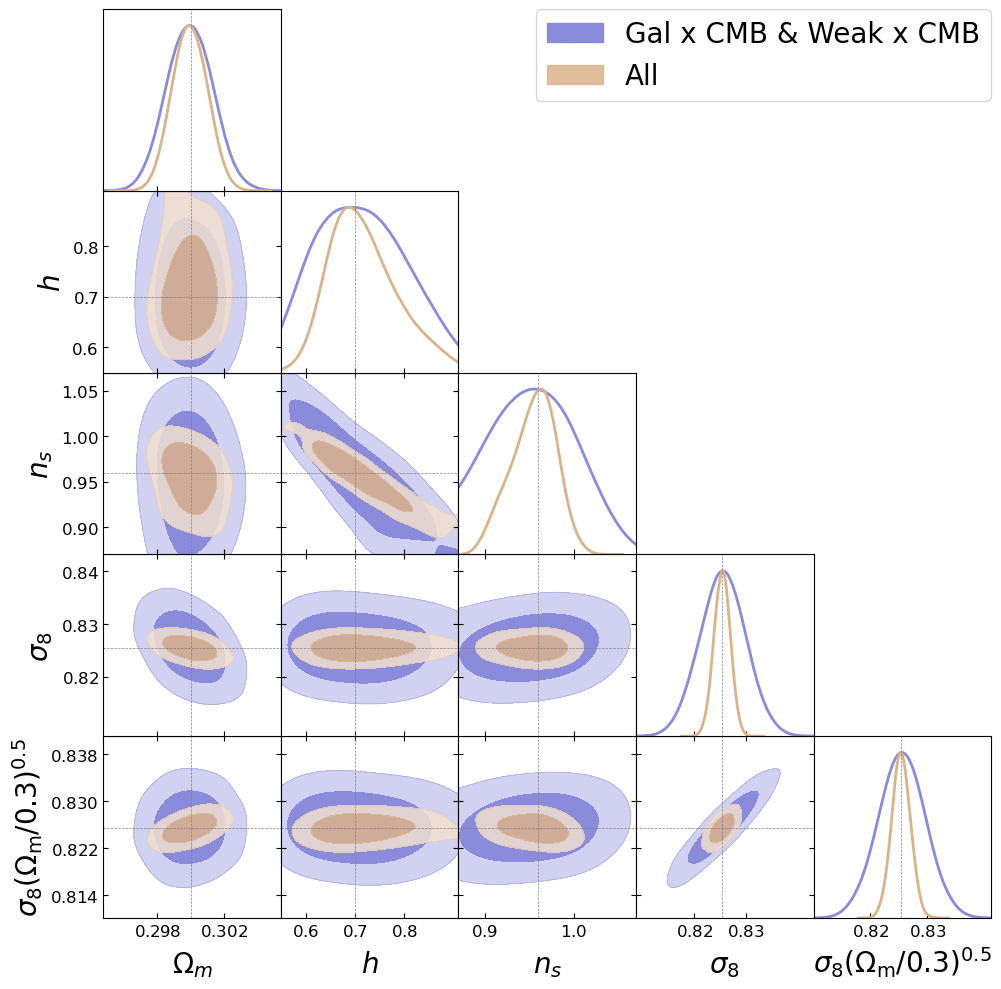

In [70]:
#COMBO PLOT

#FIX COLORS OF ONE DIM GRAPHS


plot = gdplot.triangle_plot([crosscombo_samples, all_samples], 
                     ["Omega_m","h","n_s","sigma8", "S8"], 
                     filled=True,
                     markers={"Omega_m":0.3, "h":0.7, "n_s":0.96, "sigma8":0.825395112586185, "S8":0.825395112586185},
                     legend_labels=['Gal x CMB & Weak x CMB', 'All'], 
                     colors=['#8B8BDB', '#DBB38B'],
                     line_args=[{'lw':2, 'color':'#8B8BDB'}, {'lw':2, 'color':'#DBB38B'}],
                     fontsize=18)


crosscombo_samples.getLatex() 
all_samples.getLatex()

gdplot.export(fname='cross_constraints_plot.pdf', adir='/home/s1/ggibbins/varyparams/posterplots/')


In [19]:
gdplot.settings.legend_fontsize = 27
gdplot.settings.axes_fontsize = 15
gdplot.settings.lab_fontsize = 27


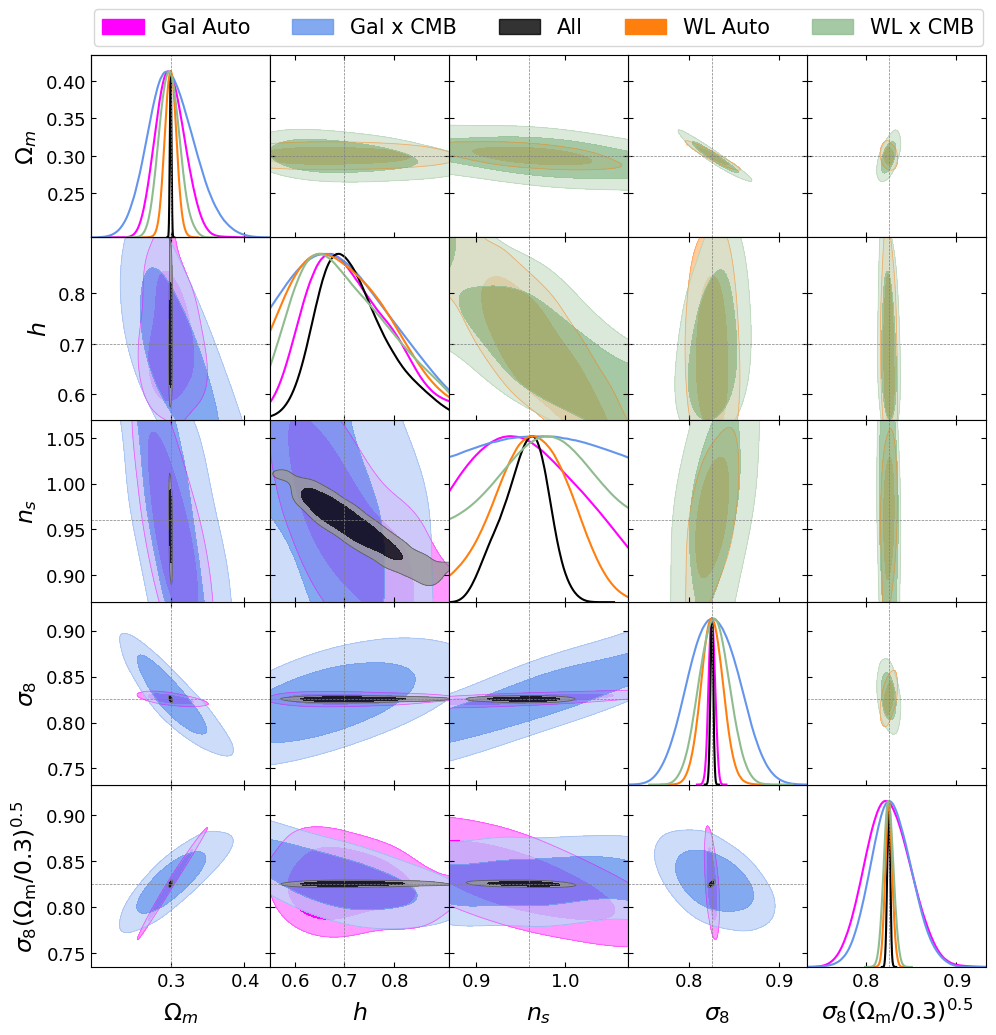

In [8]:
#Corner plot but full grid w auto and cross combos overlaying eachother

g = plots.get_subplot_plotter()
g.settings.alpha_filled_add=0.8
g.settings.legend_fontsize=18
g.settings.lab_fontsize=20
g.settings.axes_fontsize=16

g.triangle_plot([gal_samples, galcmb_samples, all_samples], 
                ["Omega_m","h","n_s","sigma8", "S8"], filled=True,
                #alpha=[.5,.3],
                colors = ['magenta','cornflowerblue','black'],
                upper_kwargs = {'contour_colors':['tab:orange', 'darkseagreen'], 'lw':[1,1.5]},
                upper_roots = [wl_samples, wlcmb_samples],
                markers={"Omega_m":0.3, "h":0.7, "n_s":0.96, "sigma8":0.825395112586185, "S8":0.825395112586185},
                legend_labels=['Gal Auto', 'Gal x CMB', 'All', 'WL Auto', 'WL x CMB'],
                plot_args=[{},{},{'alpha':1},{'alpha':.6}],
                line_args=[{'lw':1.5, 'color':'magenta'}, {'lw':1.5, 'color':'cornflowerblue'}, {'lw':1.5, 'color':'black'}, {'lw':1.5, 'color':'tab:orange'}, {'lw':1.5, 'color':'darkseagreen'}])

#colors=['magenta','cornflowerblue'],
 #               upper_kwargs = {'contour_colors':['black','lime']},

#g.export(fname='indivcontour_box_plot_MAYBLESSBADCOLORS.png', adir='/home/s1/ggibbins/varyparams/posterplots/')


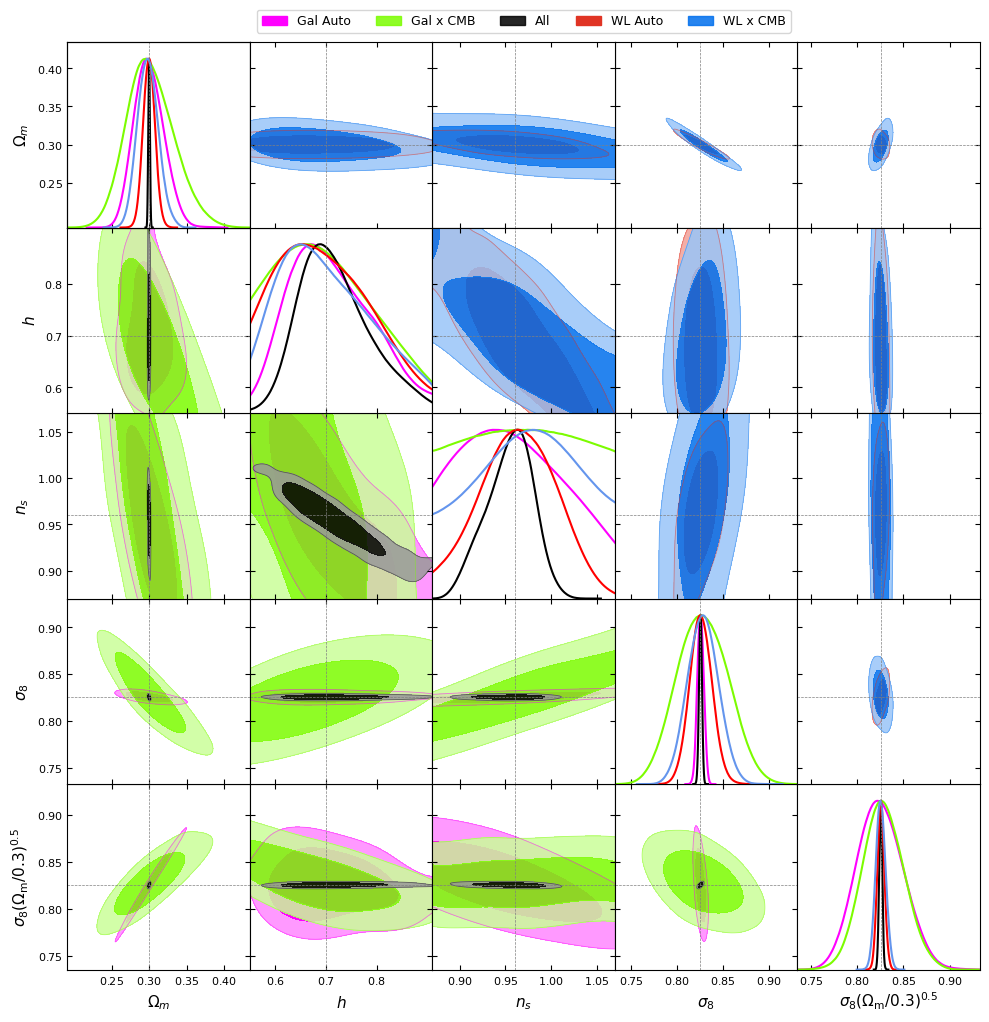

In [21]:
#Corner plot but full grid w auto and cross combos overlaying eachother

g = plots.get_subplot_plotter()
#g.settings.alpha_filled_add=0.5
g.triangle_plot([gal_samples, galcmb_samples, all_samples], 
                ["Omega_m","h","n_s","sigma8", "S8"], filled=True,
                #alpha=[.5,.3],
                colors = ['magenta','lawngreen','black'],
                upper_roots = [wl_samples, wlcmb_samples],
                markers={"Omega_m":0.3, "h":0.7, "n_s":0.96, "sigma8":0.825395112586185, "S8":0.825395112586185},
                legend_labels=['Gal Auto', 'Gal x CMB', 'All', 'WL Auto', 'WL x CMB'],
                line_args=[{'lw':1.5, 'color':'magenta'}, {'lw':1.5, 'color':'lawngreen'}, {'lw':1.5, 'color':'black'}, {'lw':1.5, 'color':'r'}, {'lw':1.5, 'color':'cornflowerblue'}])

#colors=['magenta','cornflowerblue'],
 #               upper_kwargs = {'contour_colors':['black','lime']},

#g.export(fname='indivcontour_box_plot.pdf', adir='/home/s1/ggibbins/varyparams/posterplots/')


In [ ]:
oc = np.linspace(.1, .9, 50) 
ob = np.linspace(.03, .7, 50) ~~~~~~~~~~DEP ON GABS ANSWER
h = np.linspace(.55, .91, 50) -----------------
As = np.linspace(1.89e-9,2.5e-9,50)
ns = np.linspace(.87, 1.07, 50) ---------
#ok = np.linspace() #not varying?
w0 = np.linspace(-3, -1, 50)
wa = np.linspace(-3, 1, 50)

In [97]:
#gdplt('/home/s1/ggibbins/varyparams/chain/clgg_only/chains_.covmat')
print(getdist.version())

AttributeError: module 'getdist' has no attribute 'version'

In [25]:
#gal_samples.getLatex() 
wl_samples.getLatex()
#galcmb_samples.getLatex() 
#wlcmb_samples.getLatex() 
#crosscombo_samples.getLatex() 
#all_samples.getLatex() 

(['\\Omega_c',
  '\\Omega_b',
  'h',
  'n_s',
  'A_s',
  '\\sigma_8',
  '\\Omega_m',
  '\\sigma_8 (\\Omega_\\mathrm{m}/0.3)^{0.5}',
  '\\chi^2',
  '\\chi^2_\\mathrm{like\\ kxg.like\\ kxg}'],
 ['0.250\\pm 0.013',
  '0.050\\pm 0.011',
  '0.699^{+0.066}_{-0.12}',
  '0.964\\pm 0.040',
  '2.20^{+0.31}_{-0.50}',
  '0.826\\pm 0.012',
  '0.2999\\pm 0.0079',
  '0.8256\\pm 0.0039',
  '4.1\\pm 2.8',
  '4.1\\pm 2.8'])

In [26]:
wlcmb_samples.getLatex() 

(['\\Omega_c',
  '\\Omega_b',
  'h',
  'n_s',
  'A_s',
  '\\sigma_8',
  '\\Omega_m',
  '\\sigma_8 (\\Omega_\\mathrm{m}/0.3)^{0.5}',
  '\\chi^2',
  '\\chi^2_\\mathrm{like\\ kxg.like\\ kxg}'],
 ['0.247\\pm 0.017',
  '0.051^{+0.013}_{-0.010}',
  '0.702^{+0.063}_{-0.12}',
  '0.973^{+0.066}_{-0.052}',
  '2.22^{+0.31}_{-0.48}',
  '0.828\\pm 0.017',
  '0.298\\pm 0.014',
  '0.8253\\pm 0.0054',
  '3.4\\pm 2.5',
  '3.4\\pm 2.5'])

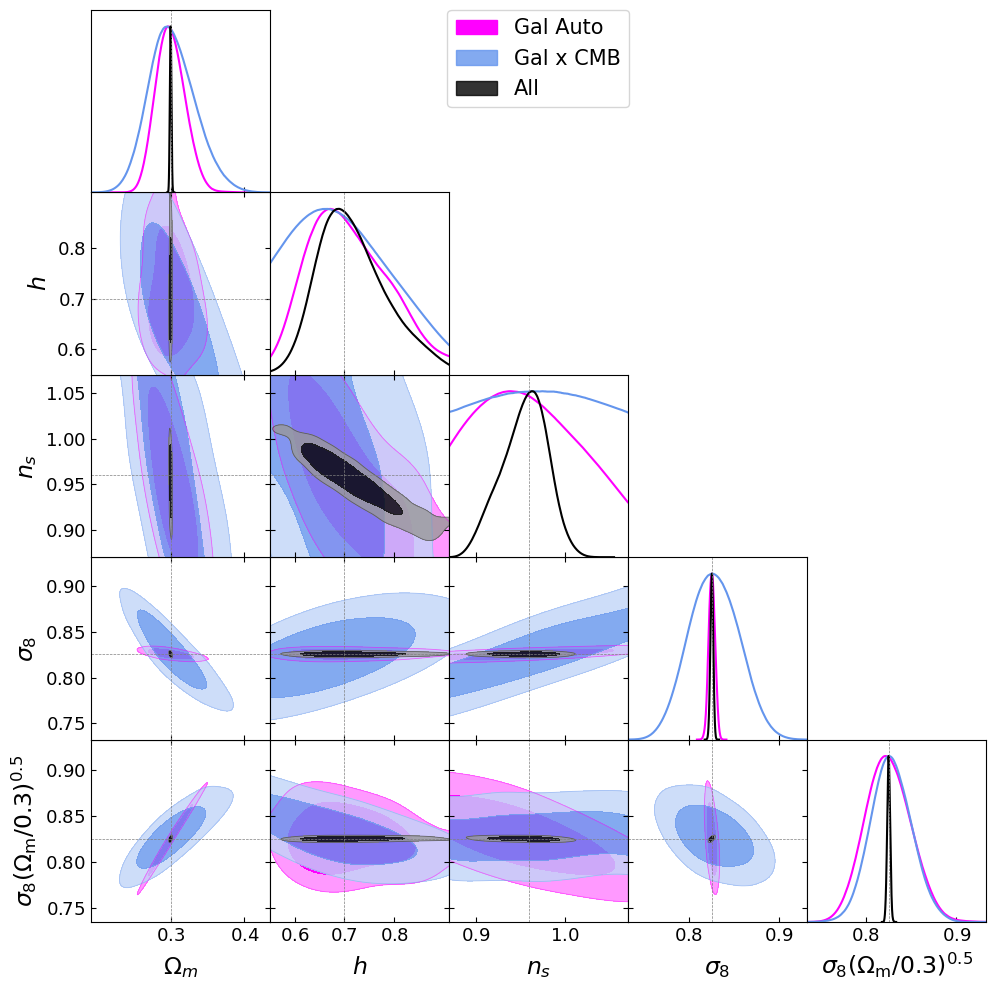

In [9]:

g = plots.get_subplot_plotter()
g.settings.alpha_filled_add=0.8
g.settings.legend_fontsize=18
g.settings.lab_fontsize=20
g.settings.axes_fontsize=16

g.triangle_plot([gal_samples, galcmb_samples, all_samples], 
                ["Omega_m","h","n_s","sigma8", "S8"], filled=True,
                colors = ['magenta','cornflowerblue','black'],
                markers={"Omega_m":0.3, "h":0.7, "n_s":0.96, "sigma8":0.825395112586185, "S8":0.825395112586185},
                legend_labels=['Gal Auto', 'Gal x CMB', 'All'],
                line_args=[{'lw':1.5, 'color':'magenta'}, {'lw':1.5, 'color':'cornflowerblue'}, {'lw':1.5, 'color':'black'}])

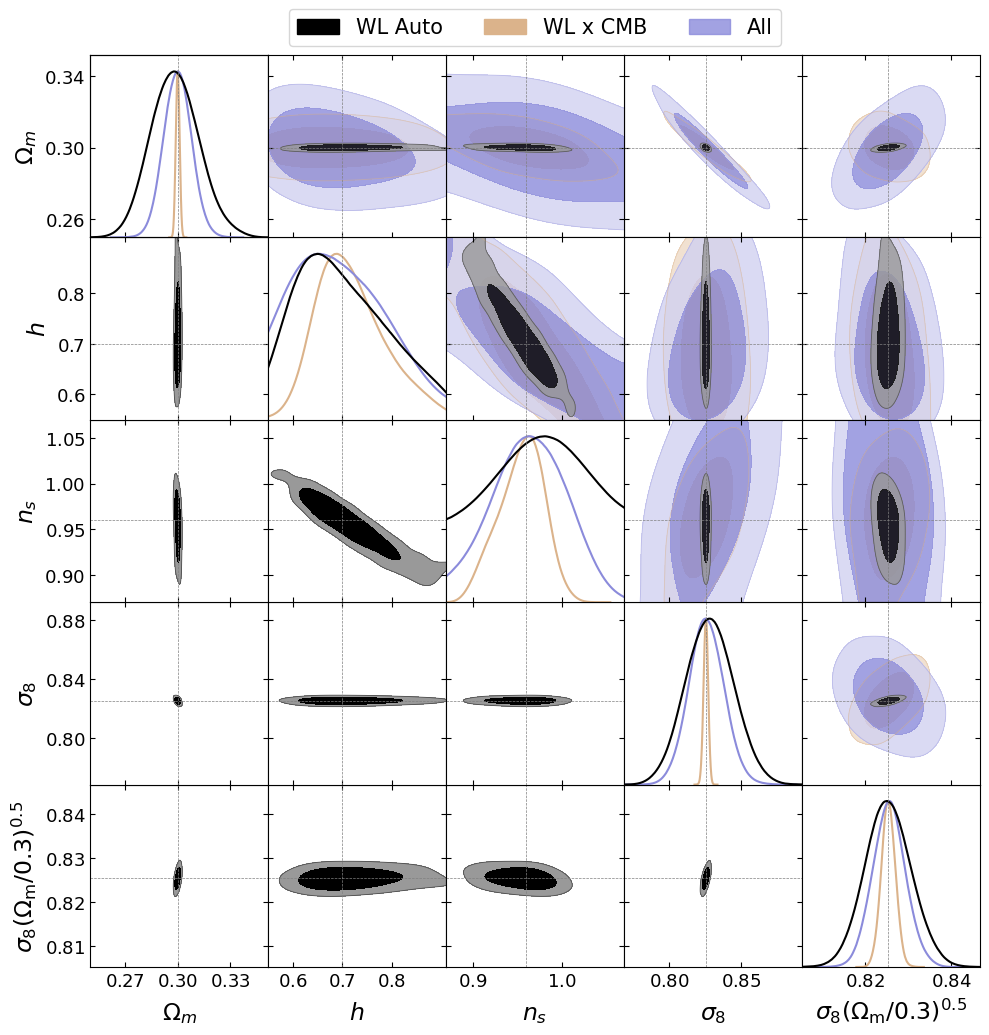

In [17]:

g = plots.get_subplot_plotter()
g.settings.alpha_filled_add=0.8
g.settings.legend_fontsize=18
g.settings.lab_fontsize=20
g.settings.axes_fontsize=16

g.triangle_plot([all_samples], ["Omega_m","h","n_s","sigma8", "S8"], filled=True,
                colors = ['black'],
                upper_kwargs = {'contour_colors':['#DBB38B', '#8B8BDB', 'black']},
                upper_roots = [wl_samples, wlcmb_samples, all_samples],
                markers={"Omega_m":0.3, "h":0.7, "n_s":0.96, "sigma8":0.825395112586185, "S8":0.825395112586185},
                legend_labels=['WL Auto', 'WL x CMB', 'All'],
                line_args=[{'lw':1.5, 'color':'#DBB38B'}, {'lw':1.5, 'color':'#8B8BDB'}, {'lw':1.5, 'color':'black'}])


In [ ]:

g = plots.get_subplot_plotter()
g.settings.alpha_filled_add=0.8
g.settings.legend_fontsize=18
g.settings.lab_fontsize=20
g.settings.axes_fontsize=16

g.triangle_plot([all_samples], ["Omega_m","h","n_s","sigma8", "S8"], filled=True,
                colors = ['black'],
                upper_kwargs = {'contour_colors':['black', '#8B8BDB', '#DBB38B'], 'alpha':[]},
                upper_roots = [all_samples, wlcmb_samples, wl_samples],
                markers={"Omega_m":0.3, "h":0.7, "n_s":0.96, "sigma8":0.825395112586185, "S8":0.825395112586185},
                legend_labels=['WL Auto', 'WL x CMB', 'All'],
                line_args=[{'lw':1.5, 'color':'#8B8BDB'}, {'lw':1.5, 'color':'#DBB38B'}, {'lw':1.5, 'color':'black'}])
